# 2. Citizen science sampling and effort reanalysis

<font size="4">

Citizen science/participatory science data are useful, but are less structured than protocol-based standardized survey. We should pay extra attention in the data processing and modeling when dealing with citizen science data.

One characteristic of citizen science data is that they are higher variable in spatiotemporal coverage and sample density, which can bias the inference. The spatiotemporal bias can include

1. More samples around cities than rural areas.
2. Overrepresentation of the birding hotspots.
3. More samples in developed regions than undeveloped regions.
4. More samples in spring and fall (migration seasons), while less samples in winter and summer (for birds).
5. Overrepresentation of diurnal species than nocturnal species.
6. More observations for colorful, easy-to-identify/observe, and common species.


Besides spatiotemporal distribution, more than a few factors can influence the quality of observations, in terms of how many species are observed and their individual counts. These include but are not limited to:

1. Whether the sampling event is complete (report all species you can identify)
2. Number of observers
3. Observer expertise
4. Observing time of the day and of the year
5. Weather conditions
6. Sampling protocol (e.g., traveling or stationary)
7. Traveling distance (if traveling).
8. Habitat structure
9. The platform and the efforts of the platform to review and correct observations, if they appear to be imprecise.

A large amount of literature has shown that considering and modeling these factors are necessary to derive standardized and comparable scientific results.

More importantly, since observers' behavior, preference, and expertise can change over time, it has been shown that the temporal trend inferred using citizen science data can be unreliable, if these factors are not being controlled. This sampling efforts shift by time is called **sampling domain shift**.


This notebook exams the legitimacy of the authors' use of citizen science data, in terms of accounting for sampling efforts, spatiotemporal debiased debiased sampling, etc.

It also look into the paper's proposed effort variable:

$$\mathrm{Duration}=\log\left(1+\frac{\mathrm{total\ recorded\ duration}}{\mathrm{reported\ birdwatcher\ count}}\right).$$

<br>

To state the conclusion upfront: **The study failed to account for most of these confounding factors, if not all of them.**

</font>

## Setup

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import pyfixest as pf
from IPython.display import Markdown, display

NOTEBOOK_DIR = Path.cwd().resolve()
DATA = NOTEBOOK_DIR.parent / "DATA"
assert DATA.is_dir()
sys.path.insert(0, str(NOTEBOOK_DIR))

import matplotlib.pyplot as plt
from load_data import build_analysis_data, read_dta, make_full_observation_grid
from regression_utils import fit_fe
from iv_observer_sensitivity import build_iv_data, fit_instrument_observer_reduced_form, fit_iv

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:.6g}")
print(f"Fixed-effects estimator: pyfixest {pf.__version__}")

Fixed-effects estimator: pyfixest 0.60.0


In [2]:
all_df, bird, policy = build_analysis_data(DATA)
df = all_df[all_df.groupby("id")["id"].transform("size") > 1].copy()

controls = ["Temp", "Wind", "Pop", "Duration", "Carbon", "Water", "Green", "Farm", "Grass"]
controls_no_duration = ["Temp", "Wind", "Pop", "Carbon", "Water", "Green", "Farm", "Grass"]

def result_row(label, result, term="PI"):
    return {
        "model": label,
        "coefficient": result[f"coef_{term}"],
        "clustered_se": result[f"se_{term}"],
        "p_value": result[f"p_{term}"],
        "n": result["n"],
    }
    

## Check the data and reanalyze the duration-per-observer ratio

In [3]:
btn_path = DATA / "BTN.dta"
btn = pd.read_stata(btn_path, convert_categoricals=False)
btn["year"] = pd.to_datetime(btn["year"])
btn["ratio"] = btn["BT"] / btn["BN"]

with pd.io.stata.StataReader(btn_path) as reader:
    labels = reader.variable_labels()

btn

,省,市,县,年月,观鸟时长,观鸟人数,year,id,BT,BN,ratio
0,北京市,北京市,东城区,201401,9,1,2014-01-01,110101,9,1,9
1,北京市,北京市,东城区,201406,0,1,2014-06-01,110101,0,1,0
2,北京市,北京市,东城区,201408,11,2,2014-08-01,110101,11,2,5.5
3,北京市,北京市,东城区,201409,12,1,2014-09-01,110101,12,1,12
4,北京市,北京市,东城区,201410,23,2,2014-10-01,110101,23,2,11.5
...,...,...,...,...,...,...,...,...,...,...,...
48897,新疆维吾尔自治区,,胡杨河市,202305,187.983,14,2023-05-01,659010,187.983,14,13.4274
48898,新疆维吾尔自治区,,胡杨河市,202306,11.75,7,2023-06-01,659010,11.75,7,1.67857
48899,新疆维吾尔自治区,,胡杨河市,202307,8.93333,10,2023-07-01,659010,8.93333,10,0.893333
48900,新疆维吾尔自治区,,胡杨河市,202308,6.35,1,2023-08-01,659010,6.35,1,6.35


In [4]:
btn.describe()


,年月,观鸟时长,观鸟人数,year,id,BT,BN,ratio
count,48902,48902,48902,48902,48902,48902,48902,48902
mean,202069,253.435,7.0848,2021-01-23 10:31:48.437282816,409675,253.742,7.08889,97.5989
min,201401,0,1,2014-01-01 00:00:00,110101,0,1,0
25%,201910,2,1,2019-10-01 00:00:00,330783,2,1,1
50%,202110,7,2,2021-10-01 00:00:00,421121,7,2,2.42857
75%,202302,28.0667,5,2023-02-01 00:00:00,510781,28.25,5,6
max,202312,110168,598,2023-12-01 00:00:00,659010,110168,598,78473.3
std,243.579,2358.44,20.5363,NaN,136535,2358.97,20.5395,1402.68


In [5]:
btn[(btn['BN']>0) & (btn['BT']==0)]

,省,市,县,年月,观鸟时长,观鸟人数,year,id,BT,BN,ratio
1,北京市,北京市,东城区,201406,0,1,2014-06-01,110101,0,1,0
8,北京市,北京市,东城区,201502,0,1,2015-02-01,110101,0,1,0
9,北京市,北京市,东城区,201504,0,4,2015-04-01,110101,0,4,0
11,北京市,北京市,东城区,201506,0,5,2015-06-01,110101,0,5,0
12,北京市,北京市,东城区,201508,0,1,2015-08-01,110101,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
48748,新疆维吾尔自治区,阿勒泰地区,吉木乃县,201506,0,1,2015-06-01,654326,0,1,0
48772,新疆维吾尔自治区,,石河子市,201507,0,1,2015-07-01,659001,0,1,0
48821,新疆维吾尔自治区,,图木舒克市,202301,0,1,2023-01-01,659003,0,1,0
48825,新疆维吾尔自治区,,五家渠市,201505,0,1,2015-05-01,659004,0,1,0


<font size="4">

It is confusing why when BN > 0 (observer count > 0), BT (total observation time) can be 0.

</font>

In [6]:
btn[btn['ratio']==1].sort_values(by='BN',ascending=False)

,省,市,县,年月,观鸟时长,观鸟人数,year,id,BT,BN,ratio
13982,安徽省,黄山市,歙县,202305,49,49,2023-05-01,341021,49,49,1
46810,宁夏回族自治区,固原市,泾源县,202306,35,35,2023-06-01,640424,35,35,1
19642,山东省,潍坊市,寒亭区,202107,27,27,2021-07-01,370703,27,27,1
17080,福建省,宁德市,福安市,202201,26,26,2022-01-01,350981,26,26,1
18141,江西省,赣州市,石城县,202208,24,24,2022-08-01,360735,24,24,1
...,...,...,...,...,...,...,...,...,...,...,...
20408,山东省,临沂市,郯城县,202301,1,1,2023-01-01,371322,1,1,1
20407,山东省,临沂市,郯城县,202106,1,1,2021-06-01,371322,1,1,1
20406,山东省,临沂市,郯城县,202104,1,1,2021-04-01,371322,1,1,1
20405,山东省,临沂市,郯城县,202102,1,1,2021-02-01,371322,1,1,1


In [7]:

ratio_one = btn[np.isclose(btn["ratio"], 1)]
duration_diff = (btn["BT"] - btn["观鸟时长"]).abs() > 1e-9
count_diff = (btn["BN"] - btn["观鸟人数"]).abs() > 1e-9

ratio_reanalysis = pd.DataFrame({
    "quantity": [
        "County-month rows",
        "Ratio above 24 hours",
        "Ratio above 744 hours (31 days!)",
        "Maximum ratio",
        "Ratio exactly one",
        "Minimum observer count when ratio equals one",
        "Maximum observer count when ratio equals one",
        "Processed duration differs from visible field",
        "Processed count differs from visible field",
        "Fractional processed observer counts",
    ],
    "value": [
        len(btn),
        (btn["ratio"] > 24).sum(),
        (btn["ratio"] > 744).sum(),
        btn["ratio"].max(),
        len(ratio_one),
        ratio_one["BN"].min(),
        ratio_one["BN"].max(),
        duration_diff.sum(),
        count_diff.sum(),
        ((btn["BN"] - btn["BN"].round()).abs() > 1e-9).sum(),
    ],
})

variables = ["观鸟时长", "观鸟人数", "BT", "BN"]
display(pd.DataFrame({"variable": variables, "Stata label": [labels.get(name) for name in variables]}))
display(ratio_reanalysis)


,variable,Stata label
0,观鸟时长,(sum) duration_hours
1,观鸟人数,(count) 数量
2,BT,观鸟时长
3,BN,观鸟人数


,quantity,value
0,County-month rows,48902
1,Ratio above 24 hours,4495
2,Ratio above 744 hours (31 days!),558
3,Maximum ratio,78473.3
4,Ratio exactly one,8656
5,Minimum observer count when ratio equals one,1
6,Maximum observer count when ratio equals one,49
7,Processed duration differs from visible field,17610
8,Processed count differs from visible field,223
9,Fractional processed observer counts,127


In [8]:
btn[btn['ratio']==btn['ratio'].max()]

,省,市,县,年月,观鸟时长,观鸟人数,year,id,BT,BN,ratio
37363,四川省,雅安市,荥经县,201405,78473.3,1,2014-05-01,511822,78473.3,1,78473.3


<font size="4">

Regardless of whether BT/BN ratio can actually represent sampling efforts, one may easily notice the issues:

1. There are 4495 county-months (9.19%) showing more than 24 hours of birding time per observer. In reality this would mean that all of these observers almost went out birding everyday during the month.
2. There are 558 county-months (1.14%) showing more than **31 days** of birding time per observer. This is out of reality since the maximum time is a month if a birder is birding non-stop day and night. This is apparently problematic.
3. If the ratio is proportional to sampling efforts, then it's hard to explain why the maximum ratio, which is 78473.3 hours per month, correspond to only one birder.

More fundamentally, BT/BN does not actually measure total sampling effort. It measures average recorded duration per reported observer. The paper’s Duration variable is the logarithm of this ratio:

$$\mathrm BT/BN={Duration}=\log\left(1+\frac{\mathrm{total\ recorded\ duration}}{\mathrm{reported\ birdwatcher\ count}}\right)$$


For example, one hour from one observer (e.g., data from 新疆维吾尔自治区 胡杨河市 202109 [province, county, and date]) and 49 hours from 49 observers (e.g., data from 安徽省 黄山市 歙县 202305 [province, city, county, and date]) **both equal one**, even though their sampling coverage can be very different. Consequently, the ratio discards information about the overall scale of sampling. Both observer count and total observation time can affect opportunities to detect species and individuals and, therefore, the estimated richness and Shannon diversity. Controlling only for their ratio does not control for these dimensions of sampling effort. We are unaware of an established citizen-science methodology that uses this ratio as the sole effort adjustment, and the paper provides neither a methodological reference nor a validation for doing so.

Citizen-science studies also commonly retain checklist-level information so that duration, observer count, protocol, distance, completeness, and other sources of variation can be controlled for at the level at which observations were collected. Pooling records into county-month averages makes this checklist-level variation untraceable and prevents direct standardization of heterogeneous sampling events. Moreover, the extreme and fractional values in the released data, together with the undocumented preprocessing, make it impossible to determine whether BN consistently represents distinct observers, summed participant counts across checklists, observation events, or some mixture of these quantities.

</font>


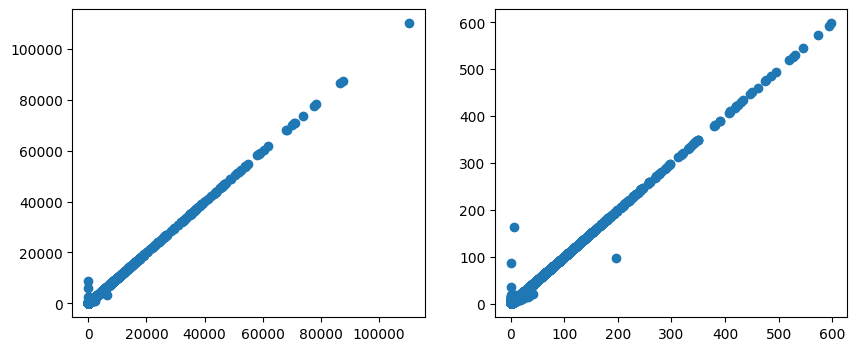

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(
    btn['观鸟时长'], btn['BT']
)
ax[1].scatter(
    btn['观鸟人数'], btn['BN']
)

<font size="4">

We can also see that issues arised even before calculating the BT/BN ratio.

Here the '观鸟时长' literally means 'bird watching duration', which is what the 'BT' is also meant to be. But it's unclear why some values are different compared to 'BT'. Similarly, '观鸟人数' should equal to 'BN', both of which mean 'number of observers'. Since the authors did not provide any description or code on how the data were acquired, filtered, and preprocessed, the reason of the mismatch is unknown. Given all the evidence, it is very likely that some calculations didn't line up at the beginning of data processing. p.s. it's not because of winsorization–we did not do that on these variables.



</font>

In [10]:
tolerance = 1e-8
richness = pd.read_stata(DATA / "Richeven.dta", convert_categoricals=False) # since the richness is winsorized in the all_df, here we merge again to see how the data looks like originally.
check = bird.merge(
    richness[["id", "YEAR", "month", "S"]],
    on=["id", "YEAR", "month"],
    how="inner",
)
check = check[check["S"] > 1].copy()

check["perfect_shannon"] = np.isclose(
    check["ShannonBD"], np.log(check["S"]), atol=tolerance, rtol=0
)
check["perfect_simpson"] = np.isclose(
    check["SimpsonBD"], 1 - 1 / check["S"], atol=tolerance, rtol=0
)
check["both_perfect"] = check["perfect_shannon"] & check["perfect_simpson"]

summary = pd.DataFrame({
    "matched observations with S > 1": [len(check)],
    "ShannonBD at perfect evenness": [check["perfect_shannon"].sum()],
    "SimpsonBD at perfect evenness": [check["perfect_simpson"].sum()],
    "both indices at perfect evenness": [check["both_perfect"].sum()],
    "share": [check["both_perfect"].mean()],
})

display(summary)

,matched observations with S > 1,ShannonBD at perfect evenness,SimpsonBD at perfect evenness,both indices at perfect evenness,share
0,44612,5208,5258,4621,0.103582


<font size="4">

Because Shannon, Simpson, and richness were winsorized in the analysis panel, we rematched the original `Bird.dta` and `Richeven.dta` files and tested whether both indices equal their theoretical perfect-evenness values, $\log(S)$ and $1-1/S$. This occurs in 4,621 of 44,612 matched county-months (10.36%), indicating that every recorded species had identical abundance in these observations. This pattern is consistent with undifferentiated or placeholder counts (e.g., spp1 = 1, spp2 = 1, spp3 = 1...), which is kown to be a possible outcome of casual counts instead of rigorous surveys. **This pattern raises concern that the original citizen-science data were not subjected to sufficiently rigorous preprocessing and quality control.**

</font>

## Check sampling effort changes over time

In [11]:
yearly = (
    btn.assign(YEAR=btn["year"].dt.year, zero_duration=(btn["BT"] == 0).astype(float))
    .groupby("YEAR", as_index=False)
    .agg(
        rows=("id", "size"),
        zero_duration_share=("zero_duration", "mean"),
        median_observers=("BN", "median"),
        median_total_time=("BT", "median"),
    )
)

correlations = pd.DataFrame({
    "effort_measure": ["log(1 + observer count)", "released duration ratio"],
    "correlation_with_richness": [
        all_df["log_BN"].corr(all_df["Richness"]),
        all_df["Duration"].corr(all_df["Richness"])
    ],
    "correlation_with_ShannonBD": [
        all_df["log_BN"].corr(all_df["ShannonBD"]),
        all_df["Duration"].corr(all_df["ShannonBD"]),
    ],
})

display(yearly)
display(correlations)

,YEAR,rows,zero_duration_share,median_observers,median_total_time
0,2014,579,0.571675,1,0
1,2015,2164,0.681146,1,0
2,2016,1967,0.243518,1,4.3
3,2017,2018,0.0178394,1,6.75833
4,2018,3112,0.0131748,1,8
5,2019,2869,0.0156849,1,8
6,2020,5016,0.0492424,2,7.8
7,2021,7978,0.00689396,2,7
8,2022,9480,0.00221519,3,8.21667
9,2023,13719,0.0017494,3,7


,effort_measure,correlation_with_richness,correlation_with_ShannonBD
0,log(1 + observer count),0.800528,0.489779
1,released duration ratio,0.257994,0.246169


<font size="4">

While it is totally confusing why BT (total observation time) can be 0 when BN > 0 (observer count > 0), we can see that this positive observer counts paired with zero duration fall from 68.1% of rows in 2015 to 0.2% in 2023, while the median observer count rises from one to three. It is possible that the old checklists were missing duration information, while as the increase of adoption of devices like mobile phone, these sampling parameters are increasingly being recorded.

This **sampling domain shift** is considered an important confounder when using citizen science data to calculate any among-year temporal trend. The study accounted for the **national-wide sampling domain shift** by including year as a fixed effect, but not county-specific platform adoption, observer composition, completeness, access, or reporting quality. If counties have different type/speed of sampling domain shifts, the model can easily take that as a true effect of PSI on biodiversity. 

A possible mechanism to explain the patterns in the study is that in counties where PSI became higher overtime, the installed PV panels on the ground changed the behavior of observers, either reducing their observation time or reducing the number of observers (it's easy to understand that a birder can be unwilling to birdwatch around solar panels). Consequently, the reduced sampling efforts can result in reduced species count, and therefore a lower observed biodiversity index. This is supported by the data, as the number of observers increase over the years, and that `observer count` correlates more strongly with `ShannonBD` and `richness` than `duration ratio` does.

In conclusion, the county-specific sampling domain shifts that this study failed to account for can produce the exact patterns in the paper.


</font>

## Does PSI predict entry into the sample and sampling intensity?

In [12]:
full_grid = make_full_observation_grid(df, bird, policy)
sample_inclusion = fit_fe(full_grid, "observed", ["PI"])
observer_count = fit_fe(df, "log_BN_w", ["PI", *controls])
total_time = fit_fe(df, "log_BT_w", ["PI", *controls_no_duration])

pi_sd = df["PI"].std()
sampling_results = pd.DataFrame([
    result_row("County-month appears in bird data (sample size)", sample_inclusion),
    result_row("Log observer count", observer_count),
    result_row("Log total observation time", total_time),
])
sampling_results["effect_of_1_SD_PSI"] = [
    100 * sample_inclusion["coef_PI"] * pi_sd,
    100 * np.expm1(observer_count["coef_PI"] * pi_sd),
    100 * np.expm1(total_time["coef_PI"] * pi_sd),
]

possible = df["id"].nunique() * 120
print(f"Observed share of possible county-months: {len(df) / possible:.1%}")
display(sampling_results)

Observed share of possible county-months: 16.5%


,model,coefficient,clustered_se,p_value,n,effect_of_1_SD_PSI
0,County-month appears in bird data (sample size),-0.00786296,0.000959938,4.20529e-16,281280,-3.23584
1,Log observer count,-0.032407,0.00500284,1.13106e-10,46371,-12.4854
2,Log total observation time,-0.0564721,0.00768234,2.70635e-13,46371,-20.7371


<font size="4">

**This result shows that PSI can predict sampling efforts. For the same county, higher PSI, lower sampling efforts (both observer count and observation time).**

These are temporal comparisons: “higher PSI” means a county's PSI is higher than its own usual level, relative to the national change in that year-month. It does not mean simply comparing high-PSI counties with low-PSI counties. The identifying PSI variation predicts fewer observers and less total recorded time.

Therefore, it is very possible that sampling efforts like observer count and observation time are the **mediators** of PSI -> observed Shannon diversity causal chain.

</font>

## Adding observer count to the model effectively eliminates the patterns

In [13]:
released = fit_fe(df, "ShannonBD", ["PI", *controls])
add_observers = fit_fe(df, "ShannonBD", ["PI", *controls, "log_BN_w"])
separate_effort = fit_fe(
    df, "ShannonBD", ["PI", *controls_no_duration, "log_BT_w", "log_BN_w"]
)

cell_count = df.groupby("county_month")["year"].transform("nunique")
repeated = df[cell_count >= 5]
stable_season = fit_fe(
    repeated,
    "ShannonBD",
    ["PI", *controls, "log_BN_w"],
    fe_columns=("county_month", "year"),
)

display(pd.DataFrame([
    result_row("Released Shannon model", released),
    result_row("Add observer count", add_observers),
    result_row("Separate total time and observer count", separate_effort),
    result_row("Repeated county-season + observer count", stable_season),
]))

,model,coefficient,clustered_se,p_value,n
0,Released Shannon model,-0.0125284,0.00365035,0.000609325,46371
1,Add observer count,0.00345219,0.00324988,0.288231,46371
2,Separate total time and observer count,0.00335114,0.00325469,0.303288,46371
3,Repeated county-season + observer count,0.00514526,0.00623439,0.409538,16573


In [14]:
## Effects in percentage
scale = 100 * df["PI"].std() / df["ShannonBD"].mean()

one_sd_effect = pd.DataFrame({
    "model": ["Released model", "Model + observer count"],
    "PSI coefficient": [
        released["coef_PI"],
        add_observers["coef_PI"],
    ],
    "Shannon change per 1-SD PSI (%)": [
        released["coef_PI"] * scale,
        add_observers["coef_PI"] * scale,
    ],
    "p-value": [
        released["p_PI"],
        add_observers["p_PI"],
    ],
})

display(one_sd_effect)

,model,PSI coefficient,Shannon change per 1-SD PSI (%),p-value
0,Released model,-0.0125284,-2.10628,0.000609325
1,Model + observer count,0.00345219,0.580384,0.288231


In [15]:
richness_released = fit_fe(df, "Richness", ["PI", *controls])
richness_adjusted = fit_fe(df, "Richness", ["PI", *controls, "log_BN_w"])

display(pd.DataFrame([
    result_row("Released richness model", richness_released),
    result_row("Richness + observer count", richness_adjusted),
]))

,model,coefficient,clustered_se,p_value,n
0,Released richness model,-0.97514,0.182608,1.01984e-07,45606
1,Richness + observer count,-0.0073654,0.0774491,0.924244,45606


<font size="4">

**Adding observer count changes the Shannon coefficient from negative and significant (-2.1%, P = 0.0006) to small, positive, and nonsignificant (+0.58%, P = 0.288); the richness coefficient nearly disappears ($\beta$ changes from -0.9751 to -0.0074).** These are consistent with the potential mechanism that fewer observers can produce lower recorded diversity because fewer people, checklists, locations, and observation-hours reduce opportunities to detect species, especially rare species. 

</font>

## Show the exact observer-count coefficient decomposition

In [16]:
observer_equation = fit_fe(df, "log_BN_w", ["PI", *controls])
full_shannon = fit_fe(
    df, "ShannonBD", ["PI", *controls, "log_BN_w"], focal="log_BN_w"
)

delta = observer_equation["coef_PI"]
gamma = full_shannon["coef_log_BN_w"]
decomposition = pd.DataFrame({
    "quantity": [
        "PSI coefficient in observer-count equation (delta)",
        "Observer coefficient in full Shannon equation (gamma)",
        "delta times gamma",
        "Released PSI coefficient minus observer-adjusted coefficient",
    ],
    "value": [delta, gamma, delta * gamma, released["coef_PI"] - add_observers["coef_PI"]],
})

with pd.option_context("display.max_colwidth", None):
    display(decomposition.style.set_properties(**{"text-align": "left"}))
    

,quantity,value
0,PSI coefficient in observer-count equation (delta),-0.032407
1,Observer coefficient in full Shannon equation (gamma),0.493120
2,delta times gamma,-0.015981
3,Released PSI coefficient minus observer-adjusted coefficient,-0.015981


<font size="4">

The negative PSI coefficient can be fully accounted for algebraically by the omission of observer count. Within counties over time, higher PSI is associated with fewer observers ($\delta=-0.0324$), while more observers are associated with higher recorded bird diversity ($\gamma=0.493$). Their product,

$$
\delta\gamma \approx -0.0160,
$$

equals the change in the estimated PSI coefficient after controlling for observer count—from $-0.0125$ to $0.0035$. This exact omitted-variable decomposition shows that observer count accounts for the entire coefficient shift, although it does not by itself establish a causal mechanism.

</font>

<font size="4">

1. Observer count omitted (the analysis in the paper)

```mermaid
%%{init: {"themeVariables": {"fontSize": "18px"}}}%%
flowchart LR
    X("Policy stringency<br/>(PSI)")
    Y("Observed Shannon diversity")

    X -->|"Estimated PSI coefficient<br/>β = −0.01253<br/>-2.1% per 1 SD<br/>P = 0.0006"| Y
```


</font>

<font size="4">

2. Observer count included (our reanalysis)

```mermaid
%%{init: {"themeVariables": {"fontSize": "18px"}}}%%
flowchart LR
    X("Policy stringency<br/>(PSI)")
    M("Observer count")
    Y("Observed Shannon diversity")

    X -->|"δ = −0.03241"| M
    M -->|"γ = +0.49312"| Y
    X -->|"new β = +0.00345<br/>+0.5% per 1 SD<br/>p = 0.288<br/>"| Y


```

</font>

## Test whether the IV removes the sampling sensitivity

In [17]:
iv_data = build_iv_data(DATA)
iv_results = pd.DataFrame([
    fit_iv(iv_data, add_observer_count=False),
    fit_iv(iv_data, add_observer_count=True),
    fit_instrument_observer_reduced_form(iv_data),
])
display(iv_results)

,model,n,clusters,estimator,pi_coefficient,pi_clustered_se,pi_p_value,first_stage_instrument_coefficient,first_stage_instrument_clustered_se,first_stage_instrument_p_value,observer_coefficient,observer_clustered_se,observer_p_value
0,Released Table S7 IV,37503,2077,pyfixest 0.60.0,-0.126369,0.0346277,0.000269381,0.0252042,0.0045805,4.20688e-08,NaN,NaN,NaN
1,IV + observer count,37503,2077,pyfixest 0.60.0,0.00298651,0.027062,0.912136,0.0242239,0.00457985,1.35742e-07,0.497073,0.0112907,1.40898e-299
2,Instrument predicts observer count,37503,2077,pyfixest 0.60.0,NaN,NaN,NaN,-0.006559,0.000777157,5.87794e-17,NaN,NaN,NaN


<font size="4">

The released IV model estimates a significant negative effect of PSI on Shannon diversity ($\beta=-0.126$, $p<0.001$), but the estimate becomes essentially zero after controlling for observer count ($\beta=0.003$, $p=0.912$), even though the instrument continues to predict PSI strongly. Observer count is strongly associated with recorded diversity, and the instrument itself significantly predicts observer count. Together, these results indicate that the original IV estimate may reflect an alternative sampling pathway—instrument $\rightarrow$ observer count $\rightarrow$ recorded diversity—rather than an effect operating exclusively through PSI, thereby raising a serious concern about the IV exclusion restriction.

</font>

## Conclusion

<font size="4">

Taken together, the released analysis does not adequately account for major changes in the citizen-science observation process. The duration-per-observer variable removes information about the total scale of sampling: county-months with substantially different numbers of observers and observation-hours can have the same value. The released effort fields also contain extreme or inconsistent values and marked reporting discontinuities. The data also show a sign of insufficiently rigorous preprocessing and quality control, since 10% of the counties reach maximum theoretical diversity score, likely a result of observers placing all '1' as individual counts for all species. Moreover, the within-county policy variation used to identify the PSI coefficient significantly predicts whether a county-month enters the sample, how many observers contribute, and how much total observation time is recorded. Exact year-month fixed effects absorb nationwide changes shared by all counties, but they do not remove these heterogeneous county-specific changes in coverage and detectability.

These sampling differences account for the headline results. Adding observer count changes the fixed-effects PSI coefficient for Shannon diversity from $-0.0125$ ($p<0.001$) to $0.0035$ ($p=0.288$), while the corresponding richness coefficient changes from $-0.975$ to $-0.007$ ($p=0.924$). The omitted-variable identity shows that observer count algebraically accounts for the entire shift in the Shannon coefficient, although this identity alone does not establish a causal mechanism. The IV result is similarly sensitive: controlling for observer count changes the PSI estimate from $-0.126$ ($p<0.001$) to $0.003$ ($p=0.912$), despite the first stage remaining significant. The instrument also strongly predicts observer count, raising concern about an alternative instrument –> sampling efforts -> diversity pathway and therefore about the exclusion restriction. Because the released data lack observer identity and experience, checklist completeness, precise locations, routes, protocols, and detection histories, they cannot distinguish genuine ecological decline from changes in sampling coverage or detectability. These findings do not establish that the true ecological effect of solar expansion is zero; they show that the paper’s claimed negative causal effect is not robustly identified from the released citizen-science data.

A further limitation is the heterogeneous and changing quality of China BirdReport observations. As birdwatching participation expands rapidly in China, the dataset plausibly includes many inexperienced observers and substantial variation in identification and counting practices. Some records appear to assign a count of one (individual count = 1) to every detected species rather than reporting actual individual abundance. Because the Shannon index is calculated from relative individual counts, this practice can make the index approximate species richness and substantially distort comparisons among county-months. Pooling records at the county-month level cannot correct checklist-level errors and may allow intensively visited hotspots and easily accessible sites to dominate the resulting diversity measure. The study does not control for observer experience, checklist quality, counting protocol, or hotspot overrepresentation, and the exact preprocessing from raw BirdReport records to the released aggregates is undocumented. We discussed these additional concerns in greater detail in the comment document.

</font>

### DAG assumed by the original IV analysis

```mermaid
%%{init: {"themeVariables": {"fontSize": "20px"}}}%%
flowchart LR
    Z["Instrument (IV) (log(historical sunshine)/CPU)"] --> X["Policy stringency (PSI)"]
    X --> Y["Observed Shannon diversity"]

    Z -. "✕ assumed absent" .-> Y

    linkStyle 2 stroke:#c0392b,stroke-width:2px,stroke-dasharray:6 4
```

<font size="4">

The dashed path represents the exclusion restriction. The instrument is assumed not to affect recorded Shannon diversity except through PSI.

</font>

<font size="4">

### DAG suggested by the sampling analysis

```mermaid
%%{init: {"themeVariables": {"fontSize": "20px"}}}%%
flowchart LR
    U["Ecological awareness,<br/> Local environmental orientation<br/>('building eco-friendly city')"] --> Z["Instrument (IV) (log(historical sunshine)/CPU)"]
    

    Z --> X["Policy stringency (PSI)"]
    X --> S
    S --> Y["Observed Shannon diversity"]
    U --> S["Sampling effort<br/>and observer composition"]
```

In this alternative DAG, PSI-related changes in sampling effort can affect **observed/recorded** rather than necessarily ecological diversity. Moreover, the changing ecological awareness and local environmental orientation may influence both the instrument and sampling effort, creating an open non-PSI pathway from the instrument to recorded Shannon diversity.

</font>